# Sales Analysis Using Python


# Import Libraries

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Load Dataset

In [5]:
df = pd.read_csv("Sales_Analysis_Dataset.csv")

# Understands the Dataset

In [46]:
df.shape

(1000, 9)

In [6]:
df.head()

,Order ID,Order Date,Customer Name,Category,Product,Region,Quantity,Sales,Profit
0,ORD100944,2025-01-01,Customer_0119,Clothing,T-Shirt,East,3,2783.00,589.30
1,ORD100783,2025-01-02,Customer_0065,Electronics,Laptop,East,4,194250.97,21523.76
2,ORD100046,2025-01-02,Customer_0183,Furniture,Desk,West,4,46589.19,8870.75
3,ORD100550,2025-01-03,Customer_0179,Clothing,Jacket,East,4,12782.87,2678.38
4,ORD100604,2025-01-03,Customer_0035,Electronics,Tablet,North,4,85945.87,14108.29


In [8]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Category', 'Product',
       'Region', 'Quantity', 'Sales', 'Profit'],
      dtype='str')

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       1000 non-null   str           
 1   Order Date     1000 non-null   datetime64[us]
 2   Customer Name  1000 non-null   str           
 3   Category       1000 non-null   str           
 4   Product        1000 non-null   str           
 5   Region         1000 non-null   str           
 6   Quantity       1000 non-null   int64         
 7   Sales          1000 non-null   float64       
 8   Profit         1000 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(5)
memory usage: 50.9 KB


In [49]:
df.tail()

,Order ID,Order Date,Customer Name,Category,Product,Region,Quantity,Sales,Profit
995,ORD100548,2025-12-30,Customer_0242,Furniture,Office Chair,East,5,40529.59,7315.40
996,ORD100903,2025-12-30,Customer_0313,Electronics,Tablet,North,4,97758.75,13261.83
997,ORD100904,2025-12-30,Customer_0049,Furniture,Bookshelf,South,2,12270.16,1993.37
998,ORD100854,2025-12-31,Customer_0361,Clothing,Jeans,South,4,7737.76,1427.56
999,ORD100672,2025-12-31,Customer_0162,Clothing,Jacket,West,3,9860.95,2351.26


In [53]:
df.describe()

,Order Date,Quantity,Sales,Profit
count,1000,1000.000000,1000.000000,1000.000000
mean,2025-06-27 19:16:19.200000,4.079000,62341.803110,8566.386030
min,2025-01-01 00:00:00,1.000000,780.400000,201.290000
25%,2025-04-05 18:00:00,2.000000,11310.272500,1905.747500
50%,2025-06-19 12:00:00,4.000000,34125.130000,5032.935000
75%,2025-09-23 00:00:00,6.000000,80118.540000,11052.485000
max,2025-12-31 00:00:00,7.000000,437368.030000,71064.360000
std,NaN,2.017134,77200.135183,10108.806997


# Check missing/duplicated values

In [9]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
Category         0
Product          0
Region           0
Quantity         0
Sales            0
Profit           0
dtype: int64

In [54]:
int(df.duplicated().sum())

0

# Sales Analysis

**#Total Sales**

In [18]:
int(df["Sales"].sum())

62341803

**#Average Sales**

In [20]:
int(df["Sales"].mean())

62341

**#Highest Sales**

In [21]:
int(df["Sales"].max())

437368

**#Lowest Sales**

In [23]:
int(df["Sales"].min())

780

**#Product with Lowest Sales**

In [55]:
df.loc[df["Sales"].idxmin(), ["Category", "Product", "Sales"]]

Category    Clothing
Product      T-Shirt
Sales          780.4
Name: 426, dtype: object

**#Product with Highest Sales**

In [56]:
df.loc[df["Sales"].idxmax(), ["Category", "Product", "Sales"]]

Category    Electronics
Product          Laptop
Sales         437368.03
Name: 834, dtype: object

# Profit Analysis

**#Total Profit**

In [60]:
int(df["Profit"].sum())

8566386

**#Maximum Profit**

In [58]:
int(df["Profit"].max())

71064

**#Minimum Profit**

In [61]:
int(df["Profit"].min())

201

**#Average Profit**

In [59]:
int(df["Profit"].mean())

8566

**#Product with Highest Profit**

In [62]:
df.loc[df["Profit"].idxmax(), ["Category", "Product", "Profit"]]

Category    Electronics
Product          Laptop
Profit         71064.36
Name: 158, dtype: object

**#Product with Lowest Profit**

In [63]:
df.loc[df["Profit"].idxmin(), ["Category", "Product", "Profit"]]

Category    Clothing
Product      T-Shirt
Profit        201.29
Name: 125, dtype: object

**#Category-wise Analysis**

In [31]:
df.groupby('Category')['Sales'].sum()

Category
Clothing        1971119.35
Electronics    42695217.86
Furniture      17675465.90
Name: Sales, dtype: float64

In [32]:
df.groupby('Category')['Profit'].sum()

Category
Clothing        437014.72
Electronics    5027215.86
Furniture      3102155.45
Name: Profit, dtype: float64

**#Sales vs Profit**

In [69]:
Category=df.groupby('Category')[['Sales','Profit']].sum()
print(Category)

                   Sales      Profit
Category                            
Clothing      1971119.35   437014.72
Electronics  42695217.86  5027215.86
Furniture    17675465.90  3102155.45


**#Date-wise Analysis**

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [14]:
df['Order Date'].dtype

dtype('<M8[us]')

In [15]:
df["Order Date"].dt.strftime("%d-%m-%Y")

0      01-01-2025
1      02-01-2025
2      02-01-2025
3      03-01-2025
4      03-01-2025
          ...    
995    30-12-2025
996    30-12-2025
997    30-12-2025
998    31-12-2025
999    31-12-2025
Name: Order Date, Length: 1000, dtype: str

# Visualizations

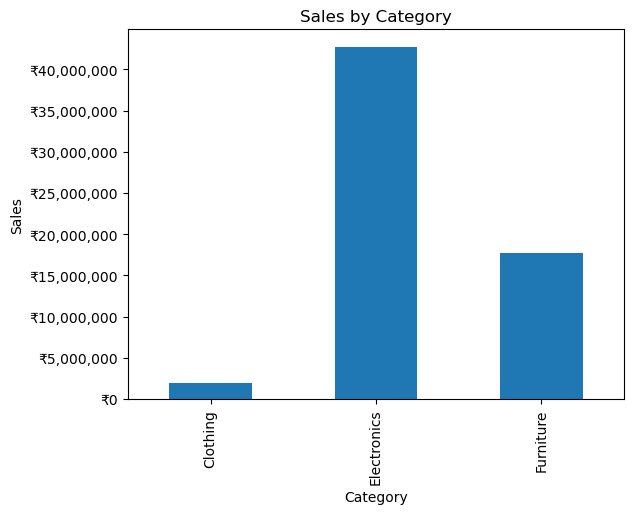

In [78]:
category= df.groupby("Category")["Sales"].sum()

ax=category.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"₹{x:,.0f}"))
plt.show()

# Sales vs Profit

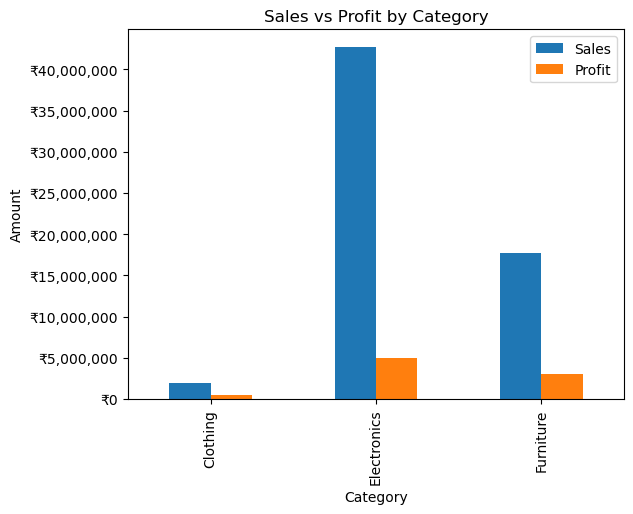

In [79]:
category= df.groupby("Category")[["Sales","Profit"]].sum()

ax=category.plot(kind="bar")
plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"₹{x:,.0f}"))
plt.show()

# Key Insights

1. The category with the highest total sales is **Electronics**.

2. The category with the highest total profit is **Electronics**.

3. Total sales are **₹62341803**.

4. Total profit is **₹8566386**.

5. The highest-selling product is **Laptop**.

6. The lowest-selling product is **T-Shirt**.

7. Sales and profit vary significantly across categories.

# Conclusion
**The Exploratory Data Analysis provided an understanding of sales performance across categories, regions and products. The analysis also identified data-quality characteristics, statistical patterns, relationships and potential outliers. These findings can help the business understand its strongest areas and identify opportunities for improvement.**